# Masks

dmpixel masks


In [1]:
source /export/CIAOT/ciaot_install/20180306/ciao-4.10/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./

CIAO configuration is complete... 
CIAO 4.10 Thursday, March  1, 2018
  bindir      : /export/CIAOT/ciaot_install/20180306/ciao-4.10/bin
  CALDB       : 4.7.8


## Setup


In [ ]:
download_chandra_obsid 16136

In [ ]:
chandra_repro 16136 ./

In [ ]:
fluximage acisf16136_repro_evt2.fits out=abell2626 bin=1 clob+

In [2]:
mkpsfmap abell2626_broad_thresh.img abell2626_broad.psfmap energy=2.3 ecf=0.9 clob+

In [3]:
punlearn wavdetect wrecon wtransform
pset wavdetect \
  infile=abell2626_broad_thresh.img \
  expfile=abell2626_broad_thresh.expmap \
  psffile=abell2626_broad.psfmap \
  outfile=abell2626.srcs \
  scellfile=abell2626.cells \
  imagefile=abell2626.recon \
  defnbkgfile=abell2626.nbkg \
  scales="1.4 2.0 4.0 8.0 12.0 16.0" \
  interdir=`pwd` clobber=yes

wavdetect mode=h


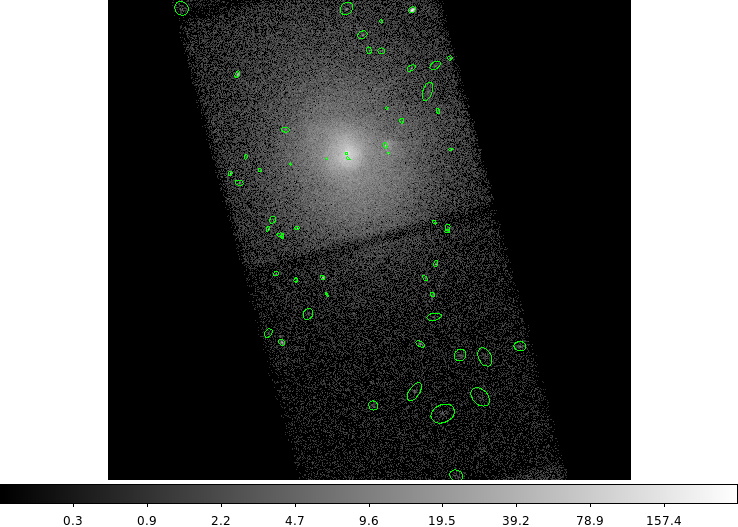

In [4]:
ds9 abell2626_broad_thresh.img -region abell2626.srcs \
  -block 4 -scale log -saveimage png ds9_01.png -quit

display < ds9_01.png

## Traditional way: regions


In [5]:
python -c 'from region import *;src=CXCRegion("abell2626.srcs");(field()-src).write("excluded_srcs.reg",fits=True,clobber=True);'
dmlist excluded_srcs.reg"[#row=1:5]" data,clean


Region Block: Field()&!Ellipse(3976.07,3767.58,10.5009,6.77157,131.978)&!Ellipse(4428.43,3822.05,13.0252,8.25924,73.7475)&!Ellipse(3815.19,3930.45,9.5287,6.53082,99.2819)&!Ellipse(3757.5,3960.5,11.1467,6.0769,61.0829)
#  POS(X,Y)                                 SHAPE              R[2]                                     ROTANG[2]                                COMPONENT
                                  NaN NaN Field                                               NaN NaN                                  NaN NaN          1
      3976.0663265306      3767.5765306122 !Ellipse                  10.5008506775         6.7715659142                       131.9777679443 NaN          1
      4428.4257425743      3822.0495049505 !Ellipse                  13.0252161026         8.2592449188                        73.7475128174 NaN          1
      3815.1914893617      3930.4468085106 !Ellipse                   9.5287017822         6.5308151245                        99.2818756104 NaN          1
     

In [6]:
dmcopy "abell2626_broad_thresh.img[sky=region(excluded_srcs.reg)]" image_point_srcs_removed_regions clob+

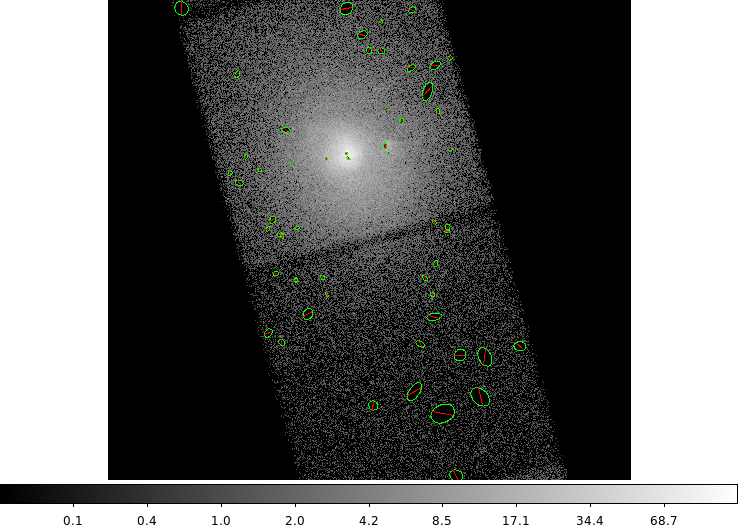

In [7]:
ds9 image_point_srcs_removed_regions -region excluded_srcs.reg \
  -block 4 -scale log -saveimage png ds9_02.png -quit

display < ds9_02.png

In [8]:
dmlist image_point_srcs_removed_regions subspace


 
--------------------------------------------------------------------------------
Data subspace for block EVENTS_IMAGE: Components: 3 Descriptors: 17 
--------------------------------------------------------------------------------
 
 --- Component 1 --- 
   1 sky                  Real8               Rectangle(3115.5,1762.5,5207.5,6070.5)&!Ellipse(3976.07,3767.58,10.5009,6.77157,131.978)&!Ellipse(4428.43,3822.05,13.0252,8.25924,73.7475)&!Ellipse(3815.19,3930.45,9.5287,6.53082,99.2819)&!Ellipse(3757.5,3960.5,11.1467,6.0769,61.0829)&!Ellipse(3874.58,3965.54,9.35435,6.95154,2.23643)&!Ellipse(3607.18,4183.19,9.9418,7.06736,73.3857)&!Ellipse(3846.73,4220.56,4.81187,3.51667,89.5624)&!Ellipse(3992.24,4241.9,3.70426,3.54155,10.6357)&!Ellipse(4071.33,4263.32,5.58344,5.06664,32.5627)&!Ellipse(4239.77,4264.7,3.91227,3.60294,131.364)&!Ellipse(4490,4279.52,9.35693,3.81444,2.35721)&!Ellipse(4226.91,4295.07,11.3243,7.12405,97.8399)&!Ellipse(3827.62,4358.72,15.8993,10.2424,175.903)&!Ellipse(4293.27,4

In [9]:
dmextract image_point_srcs_removed_regions"[sky=region(acisf16136_repro_fov1.fits)][bin sky=annulus(4077.3,4269.7,0:600:10)]" \
  exp="abell2626_broad_thresh.expmap" \
  out=radial_profile_with_regions_from_image mode=h op=generic clob+


# dmextract (CIAO 4.10): WARNING: Input file, "image_point_srcs_removed_regions[sky=region(acisf16136_repro_fov1.fits)]", has no rows in it.



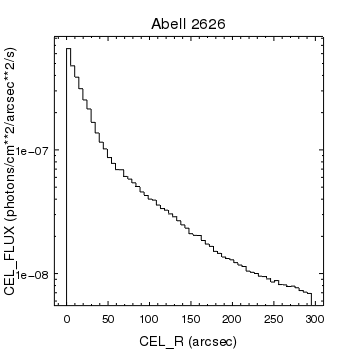

In [10]:
cat << EOM > c1.py
make_figure("radial_profile_with_regions_from_image[cols cel_r,cel_flux]","histogram")
log_scale(Y_AXIS)
print_window("chips_01.png","export.clobber=True")
quit()
EOM

chips -n c1.py
display < chips_01.png

## Using pixel masks

In [11]:
dmimgcalc abell2626_broad_thresh.img none ones.fits op="imgout=(1+(img1-img1))" clob+

In [12]:
dmstat ones.fits sig- cen- med-

ones.fits
    min:	1 	      @:	( 3116 1763 )
    max:	1 	      @:	( 3116 1763 )
   mean:	1 
    sum:	9012336 
   good:	9012336 
   null:	0 


In [13]:
dmcopy "ones.fits[sky=region(abell2626.srcs)][opt full,update=no]" srcs.mask clob+


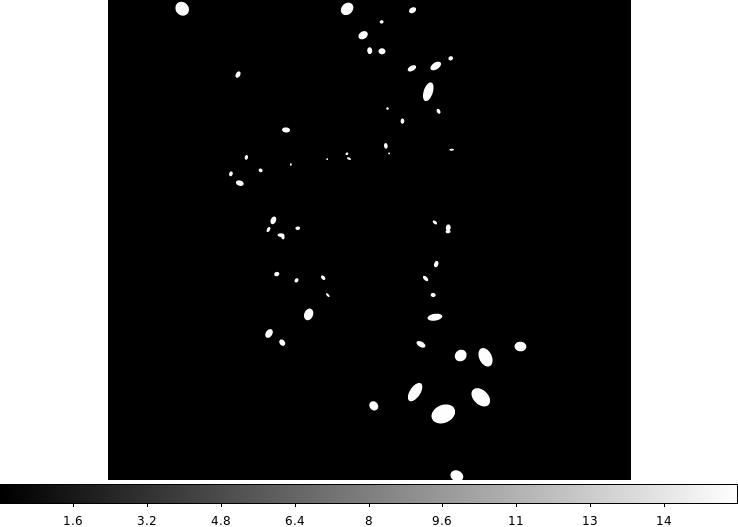

In [14]:
ds9 srcs.mask -block 4 -saveimage png ds9_03.png -quit
display < ds9_03.png

In [15]:
dmimgcalc srcs.mask none no_srcs.mask op="imgout=(1-img1)" clob+

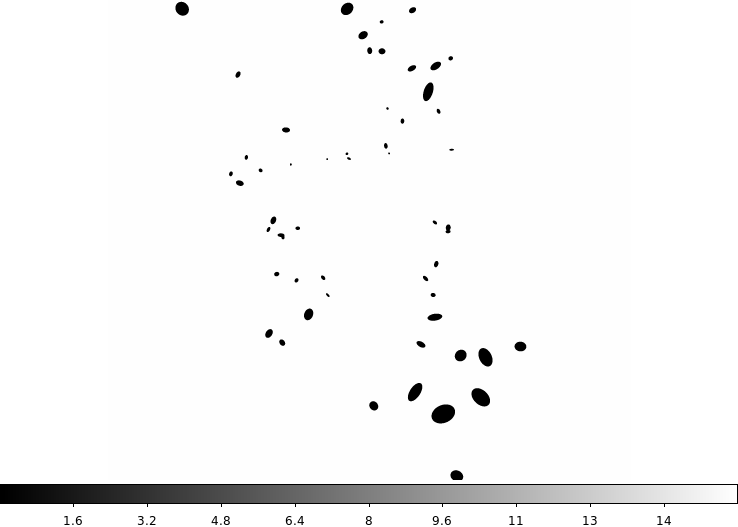

In [16]:
ds9 no_srcs.mask -block 4 -saveimage png ds9_04.png -quit
display < ds9_04.png


In [17]:
dmimgthresh no_srcs.mask out=no_srcs_with_fov.mask \
  exp=abell2626_broad_thresh.expmap \
  cut=1 value=0 clob+

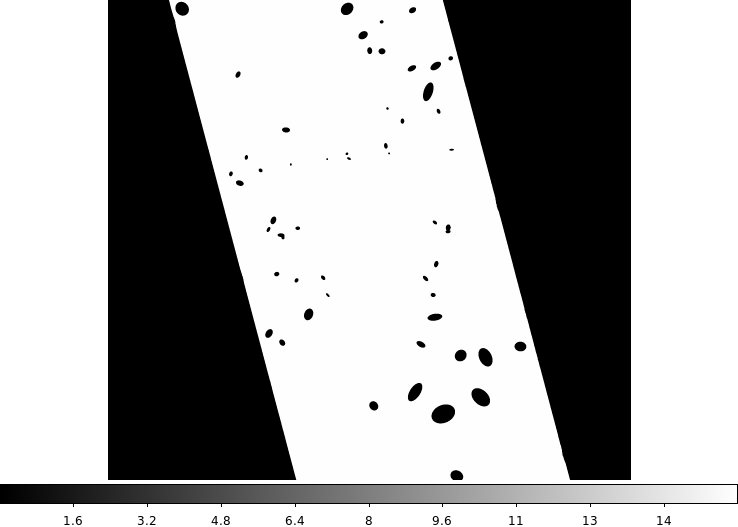

In [18]:
ds9 no_srcs_with_fov.mask -block 4 -saveimage png ds9_05.png -quit
display < ds9_05.png


### Visualize

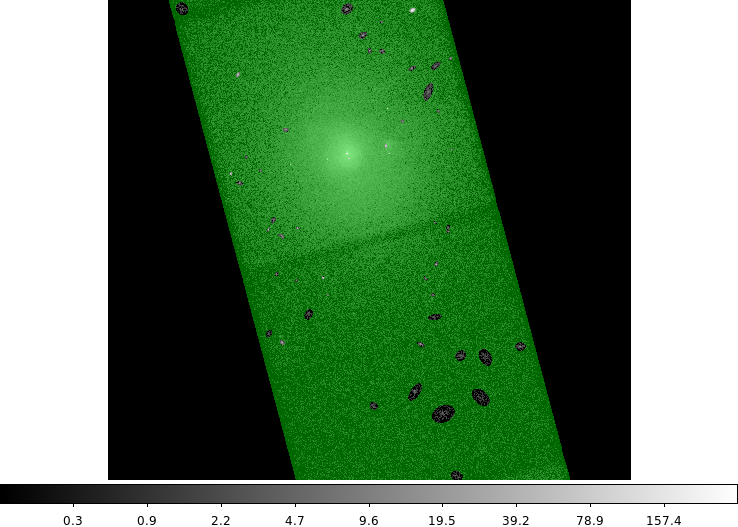

In [19]:
ds9 abell2626_broad_thresh.img -scale log \
  -block 4 -scale log -pan to 4077.3 4269.7 physical \
  -mask color green -mask transparency 60 -mask no_srcs_with_fov.mask\
  -saveimage png ds9_06.png -quit

display < ds9_06.png


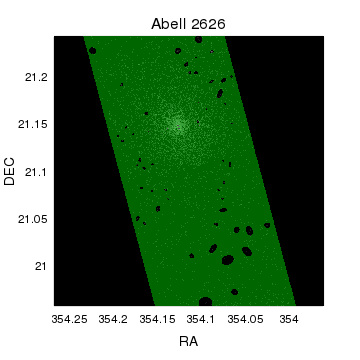

In [20]:
cat << EOM > c2.py
from crates_contrib.utils import scale_image_crate

cr = read_file("abell2626_broad_thresh.img")
scale_image_crate(cr,"asinh")

make_figure(cr,"image")

msk = read_file("no_srcs_with_fov.mask")
add_image(msk, ["alpha", [0.4,0.4], "colormap", "green"])
print_window("chips_02.png","export.clobber=True")
quit()
EOM

chips -n c2.py
display < chips_02.png


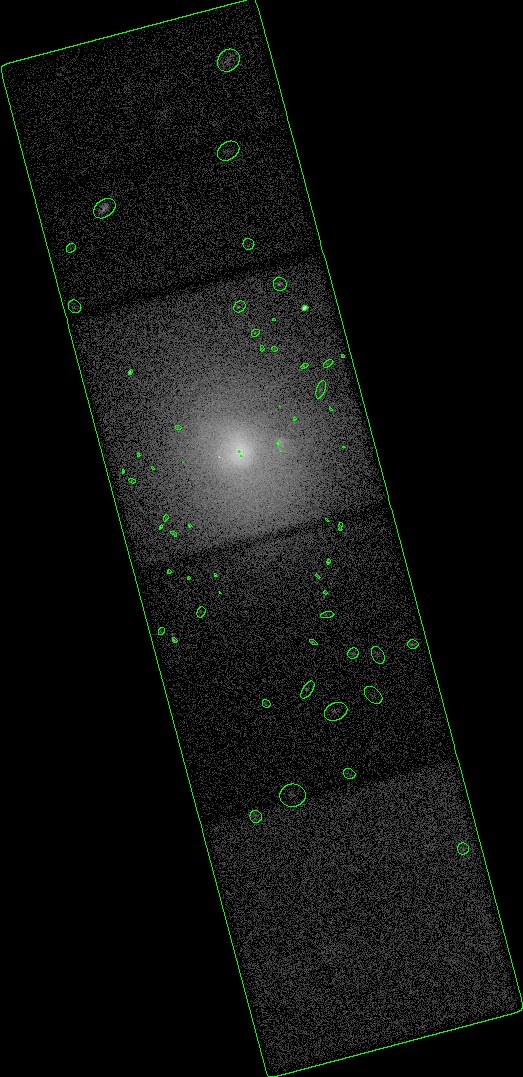

In [21]:
dmimg2jpg infile="abell2626_broad_thresh.img[bin sky=4]" \
  outfile=dmimg2jpg_40.jpg \
  regionfile="mask(no_srcs_with_fov.mask[bin sky=4])" \
  regioncolor=")colors.green" mode=h clob+

display < dmimg2jpg_40.jpg


### Filtering

In [22]:
dmcopy "abell2626_broad_thresh.img[sky=mask(no_srcs_with_fov.mask)][opt full]" image_with_mask clob+

In [23]:
dmlist image_with_mask subspace

 
--------------------------------------------------------------------------------
Data subspace for block EVENTS_IMAGE: Components: 3 Descriptors: 17 
--------------------------------------------------------------------------------
 
 --- Component 1 --- 
   1 sky                  Real8               TABLE MASK
                                              MASK(MASK)
                                              Field area = 9.01234e+06 Region area = 4.35209e+06

                          [ 1] x              
                                                   3115.50:     5207.50
                          [ 2] y              
                                                   1762.50:     6070.50
   2 expno                Int4                3:35762 
   3 ccd_id               Int2                5:5,7:7 
   4 node_id              Int2                0:3 
   5 chipx                Int2                1:1024 
   6 chipy                Int2                1:1024 
   7 tdetx              

In [24]:
dmlist image_with_mask blocks

 
--------------------------------------------------------------------------------
Dataset: image_with_mask
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: EVENTS_IMAGE                   Image      Int4(2092x4308)
Block    2: MASK                           Image      Byte(2092x4308)


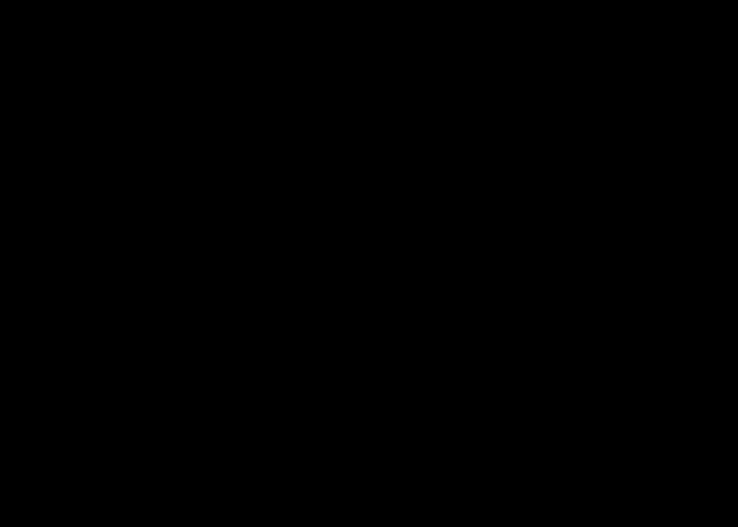

In [25]:
ds9 image_with_mask -scale log -block 4 -scale log \
  -pan to 4077.3 4269.7 physical \
  -mask color green -mask transparency 60 -mask "image_with_mask[mask]" \
  -saveimage png ds9_07.png -quit

display < ds9_07.png
  


### Make radial profile


In [26]:
 dmextract "image_with_mask[bin sky=annulus(4077.3,4269.7,0:600:10)]" \
  exp="abell2626_broad_thresh.expmap" \
  out=radial_profile_with_mask_from_image mode=h op=generic clob+


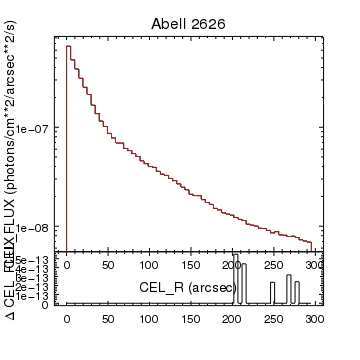

In [27]:
cat << EOM > c3.py
strip_chart(2, ratios=[4,1])

a = read_file("radial_profile_with_mask_from_image[cols cel_r,cel_flux]")
b = read_file("radial_profile_with_regions_from_image[cols cel_r,cel_flux]")
make_figure(a,"histogram")
add_histogram(b, "*.color=firebrick")
log_scale(Y_AXIS)

set_current_plot("plot2")
xx = a.get_column("cel_r").values
dd = a.get_column("cel_flux").values - b.get_column("cel_flux").values
xmid = (xx.T[0]+xx.T[1])/2.0
add_histogram(xmid,dd)
set_plot_ylabel("\Delta CEL\_FLUX")
print_window("chips_03.png","export.clobber=True")
quit()
EOM


chips -n c3.py
display < chips_03.png



In [28]:
dmdiff radial_profile_with_regions_from_image"[cols cel_flux]" radial_profile_with_mask_from_image"[cols cel_flux]" sub- key- || echo 

Infile 1:  radial_profile_with_regions_from_image[cols cel_flux]
Infile 2:  radial_profile_with_mask_from_image[cols cel_flux]


TABLE NAME: HISTOGRAM

-----------------------
TABLE VALUE DIFFERENCES
-----------------------

Message:                             Row:        Column:              Value(s):                    Diff:
--------                             ----        -------              ---------                    -----
Values are not equal                  42        CEL_FLUX 1.22601768094434e-08  1.22607280200636e-08 +5.51211e-13 (+0.0045 %)
Values are not equal                  44        CEL_FLUX 1.14021673758562e-08  1.14026103782445e-08 +4.43002e-13 (+0.00389 %)
Values are not equal                  51        CEL_FLUX 8.54549095788864e-09  8.54572658892842e-09 +2.35631e-13 (+0.00276 %)
Values are not equal                  53        CEL_FLUX 8.14868724708034e-09  8.14868724708034e-09 +1.65436e-24 (+2.03e-14 %)
Values are not equal                  55        CEL_FLUX 7.85

## FOV edges

In [29]:
dmcopy "ones.fits[sky=region(acisf16136_repro_fov1.fits)][opt full,update=no]" \
  fov.mask clob+


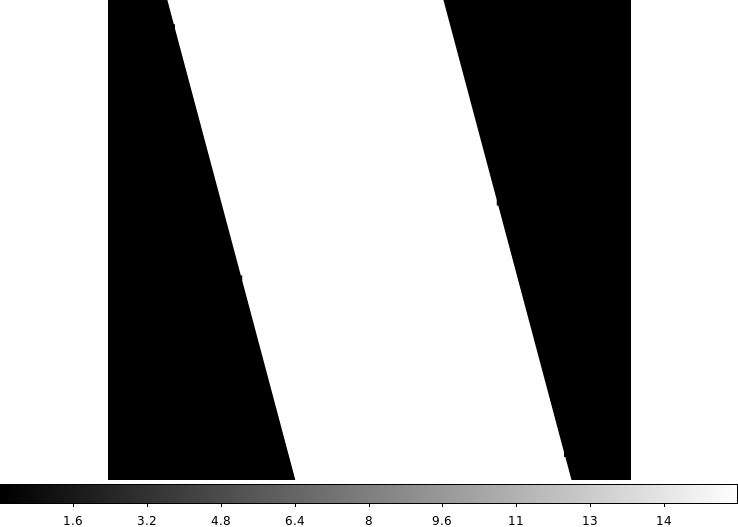

In [30]:
ds9 fov.mask -block 4 -saveimage png ds9_08.png -quit
display < ds9_08.png


In [31]:
dmimgcalc no_srcs.mask fov.mask no_srcs_fov.mask op=mul clob+

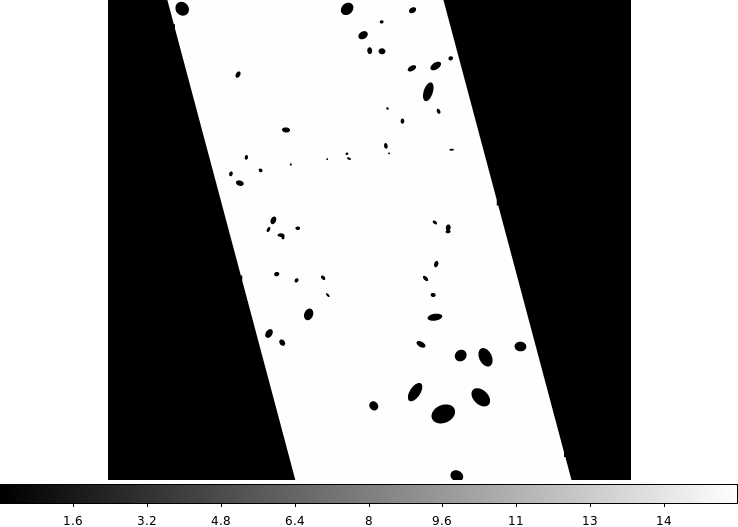

In [32]:
ds9 no_srcs_fov.mask -block 4 -saveimage png ds9_09.png -quit
display < ds9_09.png


In [33]:
dmimgcalc no_srcs_fov.mask no_srcs_with_fov.mask diff_fov.mask op=sub clob+


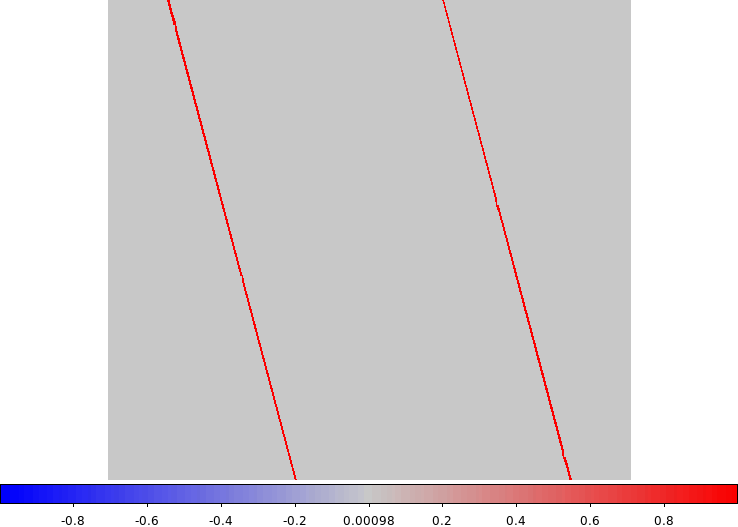

In [34]:
ds9 diff_fov.mask -block 4 -scale limits -1 1 \
  -cmap load $ASCDS_INSTALL/contrib/data/004-phase.lut \
  -saveimage png ds9_10.png -quit

display < ds9_10.png

In [35]:
dmextract "abell2626_broad_thresh.img[sky=mask(no_srcs_fov.mask)][bin sky=annulus(4077.3,4269.7,0:600:10)]" \
  exp="abell2626_broad_thresh.expmap" \
  out=radial_profile_with_mask_from_image2 mode=h op=generic clob+

# dmextract (CIAO 4.10): WARNING: Input file, "abell2626_broad_thresh.img[sky=mask(no_srcs_fov.mask)]", has no rows in it.



In [36]:
dmdiff radial_profile_with_regions_from_image"[cols cel_flux]" radial_profile_with_mask_from_image2"[cols cel_flux]"  key- sub- || echo 

Infile 1:  radial_profile_with_regions_from_image[cols cel_flux]
Infile 2:  radial_profile_with_mask_from_image2[cols cel_flux]


TABLE NAME: HISTOGRAM

-----------------------
TABLE VALUE DIFFERENCES
-----------------------

Message:                             Row:        Column:              Value(s):                    Diff:
--------                             ----        -------              ---------                    -----
Values are not equal                  42        CEL_FLUX 1.22601768094434e-08  1.22607280200636e-08 +5.51211e-13 (+0.0045 %)
Values are not equal                  44        CEL_FLUX 1.14021673758562e-08  1.14026103782445e-08 +4.43002e-13 (+0.00389 %)
Values are not equal                  51        CEL_FLUX 8.54549095788864e-09  8.54572658892842e-09 +2.35631e-13 (+0.00276 %)
Values are not equal                  55        CEL_FLUX 7.85983505037149e-09  7.86015345515113e-09 +3.18405e-13 (+0.00405 %)
Values are not equal                  57        CEL_FLUX 7.68

## With events

In [37]:
dmcopy "acisf16136_repro_evt2.fits[sky=mask(no_srcs_with_fov.mask),energy=500:7000]" \
  events_point_srcs_removed_mask clob+

In [38]:
dmlist events_point_srcs_removed_mask subspace

 
--------------------------------------------------------------------------------
Data subspace for block EVENTS: Components: 4 Descriptors: 16 
--------------------------------------------------------------------------------
 
 --- Component 1 --- 
   1 time                 Real8               TABLE GTI7
                                              
                                              498642950.2601068020:498755270.7022138238
   2 expno                Int4                3:35762 
   3 ccd_id               Int2                7:7 
   4 node_id              Int2                0:3 
   5 chip                 [ 1] chipx          1:1024 
   5 chip                 [ 2] chipy          1:1024 
   6 tdet                 [ 1] tdetx          1:8192 
   6 tdet                 [ 2] tdety          1:8192 
   7 det                  [ 1] detx               0.50:     8192.50 
   7 det                  [ 2] dety               0.50:     8192.50 
   8 sky                  Real4               

In [39]:
dmlist events_point_srcs_removed_mask blocks

 
--------------------------------------------------------------------------------
Dataset: events_point_srcs_removed_mask
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: EVENTS                         Table        16 cols x 326105   rows
Block    3: GTI7                           Table         2 cols x 1        rows
Block    4: GTI5                           Table         2 cols x 1        rows
Block    5: GTI6                           Table         2 cols x 5        rows
Block    6: GTI8                           Table         2 cols x 5        rows
Block    7: MASK                           Image      Byte(2092x4308)


In [40]:
dmextract events_point_srcs_removed_mask"[bin sky=annulus(4077.3,4269.7,0:600:10)]" \
  exp="abell2626_broad_thresh.expmap" \
  out=radial_profile_with_mask mode=h op=generic clob+


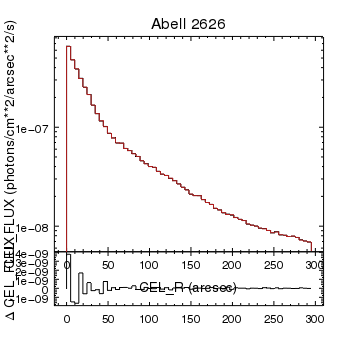

In [41]:
cat << EOM > c4.py
strip_chart(2, ratios=[4,1])

a = read_file("radial_profile_with_mask_from_image[cols cel_r,cel_flux]")
b = read_file("radial_profile_with_mask[cols cel_r,cel_flux]")

make_figure(a,"histogram")
add_histogram(b, "*.color=firebrick")
log_scale(Y_AXIS)

set_current_plot("plot2")
xx = a.get_column("cel_r").values
dd = a.get_column("cel_flux").values - b.get_column("cel_flux").values
xmid = (xx.T[0]+xx.T[1])/2.0

add_histogram(xmid,dd)
set_plot_ylabel("\Delta CEL\_FLUX")
print_window("chips_04.png","export.clobber=True")
quit()
EOM

chips -n c4.py
display < chips_04.png

